# Self-Symmetry SSIM for RHEED Azimuth Alignment
### Analysis of saved phi-scan frames 

This notebook reconstructs the azimuthal-alignment metric ** 

**Method in one sentence:** a RHEED diffraction pattern is mirror-symmetric about a vertical
axis only when the beam is aligned to a crystallographic zone axis (here `[110]`); we therefore
score each frame by how similar its **mirror-flipped left half** is to its **right half**, using
the **Structural Similarity Index (SSIM)**, and take the angle of maximum symmetry as the
optimal azimuth.

**Pipeline**
- **Detection** - run **once** on the first frame (beam, specular, tilt, mirror axis).
- **Per-frame processing** - run on **every** frame:
  1. Tilt correction
  2. Direct-beam masking
  3. Difference-of-Gaussians band-pass `DoG(3,20)`
  4. Standardization
- **Scoring** - self-symmetry SSIM of the processed frame.

## 0. Imports

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, center_of_mass, rotate
from scipy.optimize import curve_fit
from skimage.metrics import structural_similarity as ssim
from skimage.filters import difference_of_gaussians

## 1. load dataset

In [ ]:
# ====== Load data ======
DATA_PREFIX = 'rheed_align_optimized_new substrate for RHEED_5 deg'
# ================================================================

# Motor calibration / known [110] (used only to label the final plot)
MOTOR_OFFSET   = 18.757
ZONE_110_MOTOR = 66.201
ZONE_110_USER  = ZONE_110_MOTOR - MOTOR_OFFSET   # command angle of [110]

# Method hyper-parameters
APPLY_TILT_CORRECTION        = True
DOG_LOW_SIGMA                = 3      # DoG inner sigma (px)
DOG_HIGH_SIGMA               = 20     # DoG outer sigma (px)
BEAM_DETECTION_THRESHOLD     = 99.5   # percentile for the direct beam
SPECULAR_DETECTION_THRESHOLD = 98.0   # percentile for the specular spot
BEAM_MASK_EXPANSION          = 5      # grow the beam mask by this many px
SSIM_WIN                     = 7      # SSIM comparison window (odd)

## 2. Load the saved phi-scan frames

frames : (102, 540, 720, 1)  dtype=uint16
angles : (102,)  42.44 .. 52.54 deg  (N=102)


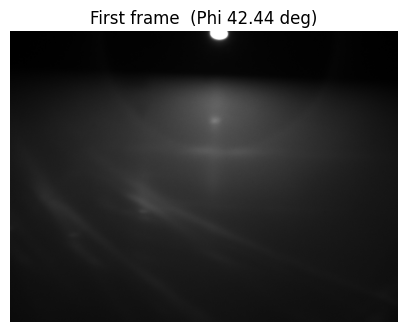

In [3]:
frames = np.load(f'{DATA_PREFIX}_images.npy')   # (N, H, W, 1) raw RHEED frames
angles = np.load(f'{DATA_PREFIX}_angles.npy')   # (N,) command angle for each frame

N, H, W = frames.shape[0], frames.shape[1], frames.shape[2]
print(f'frames : {frames.shape}  dtype={frames.dtype}')
print(f'angles : {angles.shape}  {angles.min():.2f} .. {angles.max():.2f} deg  (N={N})')

plt.figure(figsize=(5, 4))
plt.imshow(np.squeeze(frames[0]), cmap='gray')
plt.title(f'First frame  (Phi {angles[0]:.2f} deg)')
plt.axis('off')
plt.show()

## 2b. Quick look - play all frames as a video

An inline player (press play, or drag the slider) to scrub through the whole phi scan and get a
feel for the dataset. Brightness is held fixed across frames so changes are real, not auto-scaling.
Increase `STEP` for a lighter/faster video.

In [ ]:
# NOTE: this cell builds an inline animation (anim.to_jshtml()). Its large
# embedded-video output is cleared here because GitHub does not render it and
# it prevented the notebook from displaying. Run the cell locally to view it.
from matplotlib import animation
from IPython.display import HTML
plt.rcParams['animation.embed_limit'] = 60   # MB (room for ~100 frames)

STEP = 1                                  # set 2 or 3 for a lighter / faster video
idxs = list(range(0, len(frames), STEP))
vmax = float(np.percentile(frames, 99.5)) # fixed brightness so frames are comparable

fig, ax = plt.subplots(figsize=(5.6, 4.3))
im  = ax.imshow(np.squeeze(frames[0]), cmap='gray', vmin=float(frames.min()), vmax=vmax)
ttl = ax.set_title('')
ax.axis('off')

def _update(i):
    im.set_array(np.squeeze(frames[i]))
    use_scores = 'scores' in globals() and len(scores) == len(frames)
    extra = f' | SSIM={scores[i]:.3f}' if use_scores else ''
    ttl.set_text(f'frame {i}/{len(frames) - 1}  |  {angles[i]:.2f} deg{extra}')
    return (im, ttl)

anim = animation.FuncAnimation(fig, _update, frames=idxs, interval=120, blit=False)
plt.close(fig)            # avoid a duplicate static image next to the player
HTML(anim.to_jshtml())

## 3. Detection - runs **once** on the first frame

During an azimuthal scan only the crystal rotates; the camera, the direct beam and the specular
reflection stay fixed. So the geometry is measured a single time, on frame 0, and reused for
every frame. We detect:

1. **Direct beam** - the brightest blob in the top half (>= 99.5th percentile). Defines a circular
   mask.
2. **Specular spot** - the brightest blob below the beam (>= 98th percentile). Its x-position is the
   **mirror axis (midline)**.
3. **Tilt** - the angle of the beam->specular vector away from vertical. Every frame is later
   de-rotated by this angle so the mirror axis is truly vertical.

The cell below defines the detector and runs it on frame 0.

direct beam : (y=7, x=387), r=18.9 px
specular    : (y=170, x=382), r=77.9 px
tilt angle  : -1.76 deg
mirror axis : x = 382 px


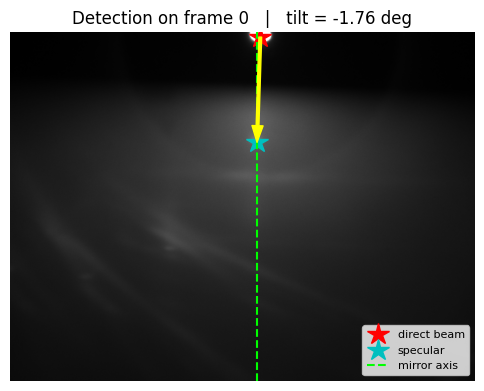

In [5]:
def detect_spot(image, threshold_percentile, region_mask=None):
    # Detect the brightest connected blob; return (cy, cx, radius, circular_mask).
    img = image.mean(axis=-1) if image.ndim == 3 else image.astype(float)
    img_search = img.copy()
    if region_mask is not None:
        img_search[~region_mask] = 0
    threshold = np.percentile(img, threshold_percentile)
    labeled, n = label(img_search > threshold)
    if n == 0:
        return None, None, None, None
    # choose the component with the highest mean intensity
    best, best_int = 1, 0.0
    for i in range(1, n + 1):
        comp = labeled == i
        mi = img[comp].mean()
        if mi > best_int:
            best_int, best = mi, i
    spot = labeled == best
    cy, cx = center_of_mass(spot)
    ys, xs = np.where(spot)
    radius = np.sqrt((ys - cy) ** 2 + (xs - cx) ** 2).max()
    Y, X = np.ogrid[:img.shape[0], :img.shape[1]]
    circle = (Y - cy) ** 2 + (X - cx) ** 2 <= (radius + BEAM_MASK_EXPANSION) ** 2
    return int(cy), int(cx), radius, circle


def detect_beam_and_specular(image):
    # Detect direct beam (top half) and specular (below beam); compute tilt from vertical.
    Hh, Ww = image.shape[:2]
    top = np.zeros((Hh, Ww), bool); top[:Hh // 2, :] = True
    by, bx, br, bmask = detect_spot(image, BEAM_DETECTION_THRESHOLD, top)
    if by is None:
        return None, None, 0.0
    bottom = np.zeros((Hh, Ww), bool); bottom[by + int(br) + 10:, :] = True
    sy, sx, sr, smask = detect_spot(image, SPECULAR_DETECTION_THRESHOLD, bottom)
    if sy is None:
        return (by, bx, br, bmask), None, 0.0
    tilt = np.degrees(np.arctan2(sx - bx, sy - by))
    return (by, bx, br, bmask), (sy, sx, sr, smask), tilt


def find_midline_from_specular(specular_info, image_width):
    # Mirror axis = specular x-position (fallback: image center).
    if specular_info is None:
        return image_width // 2
    return specular_info[1]


# ---- run detection once, on the first frame ----
beam_info, specular_info, tilt_angle = detect_beam_and_specular(frames[0])
beam_mask = beam_info[3]
midline = find_midline_from_specular(specular_info, W)

print(f'direct beam : (y={beam_info[0]}, x={beam_info[1]}), r={beam_info[2]:.1f} px')
if specular_info is not None:
    print(f'specular    : (y={specular_info[0]}, x={specular_info[1]}), r={specular_info[2]:.1f} px')
print(f'tilt angle  : {tilt_angle:.2f} deg')
print(f'mirror axis : x = {midline} px')

# ---- visualize the detection ----
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(np.squeeze(frames[0]), cmap='gray')
ax.plot(beam_info[1], beam_info[0], 'r*', ms=16, label='direct beam')
if specular_info is not None:
    ax.plot(specular_info[1], specular_info[0], 'c*', ms=16, label='specular')
    ax.annotate('', xy=(specular_info[1], specular_info[0]),
                xytext=(beam_info[1], beam_info[0]),
                arrowprops=dict(color='yellow', width=2, headwidth=8))
ax.axvline(midline, color='lime', ls='--', lw=1.5, label='mirror axis')
ax.set_title(f'Detection on frame 0   |   tilt = {tilt_angle:.2f} deg')
ax.legend(loc='lower right', fontsize=8)
ax.axis('off')
plt.show()

## 4. Per-frame processing

Steps 1-4 are applied to **every** frame. They are demonstrated here on a single example frame -
by default a near-aligned (symmetric) one - so each operation is visible. Change `EXAMPLE_IDX`
to inspect any frame (e.g. an off-axis, asymmetric one).

### Step 1 - Tilt correction

Rotate the frame by `-tilt` so the symmetry axis becomes vertical. The beam mask is rotated by the
same angle so it keeps covering the beam.

Example frame 50  (command 47.44 deg)


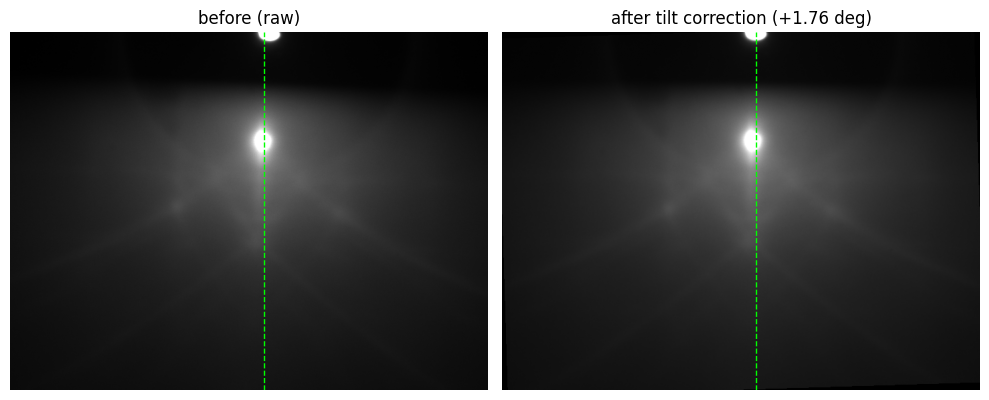

In [6]:
EXAMPLE_IDX = int(np.argmin(np.abs(angles - ZONE_110_USER)))   # a near-aligned, symmetric frame
# EXAMPLE_IDX = 0     # <-- uncomment / change to see an off-axis (asymmetric) frame

ex = frames[EXAMPLE_IDX].astype(float)
print(f'Example frame {EXAMPLE_IDX}  (command {angles[EXAMPLE_IDX]:.2f} deg)')

if APPLY_TILT_CORRECTION and abs(tilt_angle) > 0.1:
    ex_tilt       = rotate(ex, -tilt_angle, reshape=False, order=1)
    beam_mask_rot = rotate(beam_mask.astype(float), -tilt_angle, reshape=False, order=0) > 0.5
else:
    ex_tilt, beam_mask_rot = ex, beam_mask

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(np.squeeze(ex), cmap='gray');      ax[0].set_title('before (raw)')
ax[1].imshow(np.squeeze(ex_tilt), cmap='gray'); ax[1].set_title(f'after tilt correction ({-tilt_angle:+.2f} deg)')
for a in ax:
    a.axvline(midline, color='lime', ls='--', lw=1)
    a.axis('off')
plt.tight_layout(); plt.show()

### Step 2 - Direct-beam masking

Zero the pixels inside the beam circle. The intense direct beam is mirror-symmetric at *any*
azimuth, so leaving it in would inflate the symmetry score regardless of alignment.

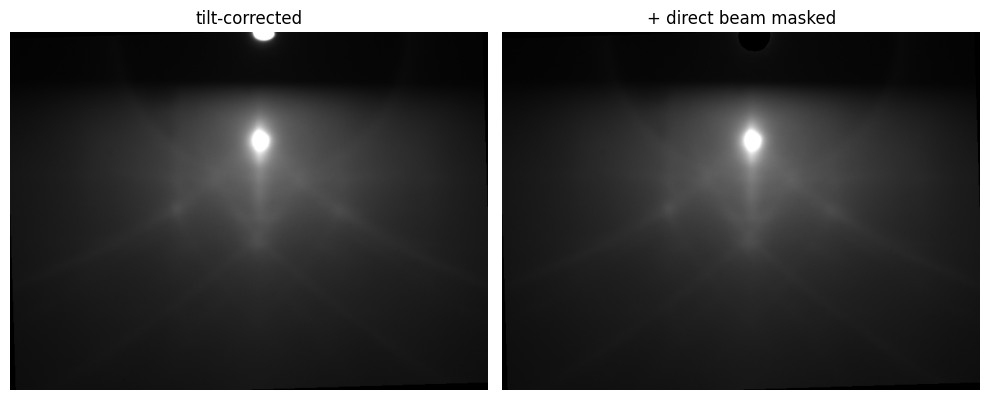

In [7]:
ex_masked = ex_tilt.copy()
ex_masked[beam_mask_rot] = 0

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(np.squeeze(ex_tilt),   cmap='gray'); ax[0].set_title('tilt-corrected')
ax[1].imshow(np.squeeze(ex_masked), cmap='gray'); ax[1].set_title('+ direct beam masked')
for a in ax:
    a.axis('off')
plt.tight_layout(); plt.show()

### Step 3 - Difference-of-Gaussians band-pass `DoG(3, 20)`

Subtract a sigma=20 Gaussian blur from a sigma=3 blur. This keeps structures between roughly 3 and
20 px (the diffraction streaks and spots) while removing pixel noise (finer than 3 px) and slow
background gradients (coarser than 20 px). This is the step that gives the symmetry signal its
contrast.

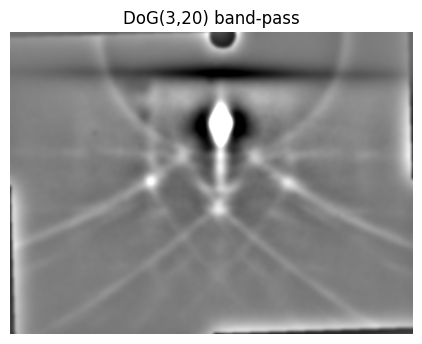

In [8]:
ex_dog = difference_of_gaussians(ex_masked, DOG_LOW_SIGMA, DOG_HIGH_SIGMA, channel_axis=-1)

v = np.percentile(np.abs(np.squeeze(ex_dog)), 99)
plt.figure(figsize=(5.2, 4.2))
plt.imshow(np.squeeze(ex_dog), cmap='gray', vmin=-v, vmax=v)
plt.title(f'DoG({DOG_LOW_SIGMA},{DOG_HIGH_SIGMA}) band-pass')
plt.axis('off'); plt.show()

### Step 4 - Standardization

Rescale to zero mean and unit variance. This makes frames comparable and sets a well-defined
`data_range = 1` for SSIM. **The output of this step is exactly the array fed to SSIM.**

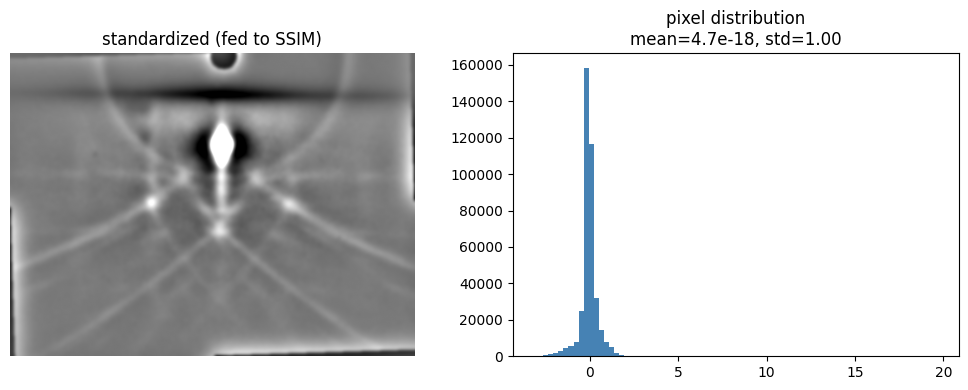

In [9]:
mu, sigma = ex_dog.mean(), ex_dog.std()
ex_proc = (ex_dog - mu) / sigma if sigma > 0 else ex_dog

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
v = np.percentile(np.abs(np.squeeze(ex_proc)), 99)
ax[0].imshow(np.squeeze(ex_proc), cmap='gray', vmin=-v, vmax=v)
ax[0].set_title('standardized (fed to SSIM)'); ax[0].axis('off')
ax[1].hist(np.squeeze(ex_proc).ravel(), bins=80, color='steelblue')
ax[1].set_title(f'pixel distribution\nmean={ex_proc.mean():.1e}, std={ex_proc.std():.2f}')
plt.tight_layout(); plt.show()

## 5. Scoring - self-symmetry SSIM

The **Structural Similarity Index** compares two images over small sliding windows, combining
luminance, contrast and structure terms:

$$\mathrm{SSIM}(x,y)=\frac{(2\mu_x\mu_y+C_1)\,(2\sigma_{xy}+C_2)}{(\mu_x^2+\mu_y^2+C_1)\,(\sigma_x^2+\sigma_y^2+C_2)}$$

with $C_1=(0.01\,L)^2$, $C_2=(0.03\,L)^2$, $L$ the data range, evaluated on $7\times7$ windows and
averaged over the image (mean SSIM).

Here SSIM is used as a **self-symmetry** measure. Split the processed frame at the mirror axis,
flip the left half horizontally, and compute SSIM between the flipped-left and the right:

$$\text{score} = \mathrm{SSIM}\!\big(\,\mathrm{flip}(\text{left}),\ \text{right}\,\big)$$

A perfectly mirror-symmetric pattern gives flipped-left == right and SSIM ~ 1; off-axis the
symmetry breaks and the score drops. The cell below shows the two halves being compared and the
per-pixel disagreement for the example frame.

self-symmetry SSIM (frame 50) = 0.2946


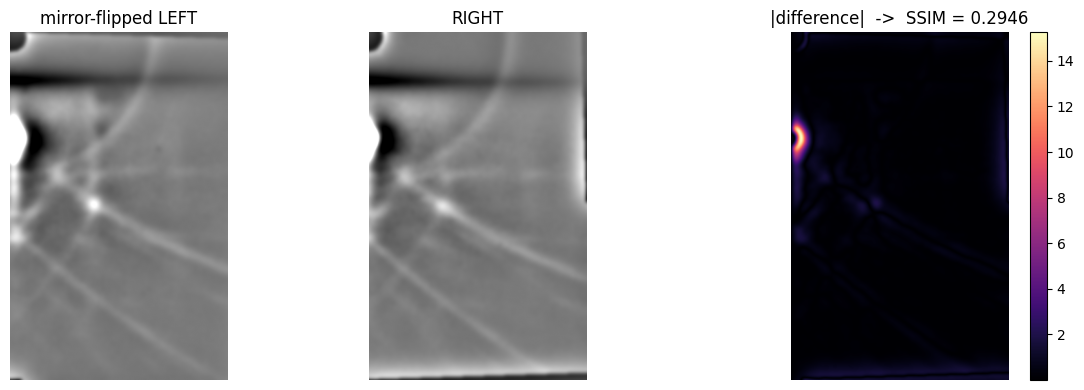

In [10]:
# split at the midline and crop both halves to equal width
m = max(10, min(W - 10, midline))
left  = ex_proc[:, :m]
right = ex_proc[:, m:]
w = min(left.shape[1], right.shape[1])
left  = left[:, -w:]
right = right[:, :w]
left_flip = np.flip(left, axis=1)

win = min(SSIM_WIN, w // 2 * 2 + 1)
score_example = ssim(left_flip, right, channel_axis=-1, win_size=win, data_range=1.0)
print(f'self-symmetry SSIM (frame {EXAMPLE_IDX}) = {score_example:.4f}')

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
v = np.percentile(np.abs(np.squeeze(ex_proc)), 99)
ax[0].imshow(np.squeeze(left_flip), cmap='gray', vmin=-v, vmax=v); ax[0].set_title('mirror-flipped LEFT')
ax[1].imshow(np.squeeze(right),     cmap='gray', vmin=-v, vmax=v); ax[1].set_title('RIGHT')
d = np.abs(np.squeeze(left_flip) - np.squeeze(right))
im = ax[2].imshow(d, cmap='magma'); ax[2].set_title(f'|difference|  ->  SSIM = {score_example:.4f}')
for a in ax:
    a.axis('off')
fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

## 6. Apply to all frames -> SSIM-vs-angle curve

Wrap Steps 1-4 (`process_frame`) and the scoring (`self_symmetry_ssim`) into two functions and run
them over every saved frame. If the dataset ships a `*_scores.npy`, we cross-check that this
reproduces it.

In [11]:
def process_frame(frame):
    # Steps 1-4: tilt-correct -> mask beam -> DoG band-pass -> standardize.
    img = frame.astype(float).copy()
    bmask = beam_mask
    if APPLY_TILT_CORRECTION and abs(tilt_angle) > 0.1:
        img   = rotate(img, -tilt_angle, reshape=False, order=1)
        bmask = rotate(beam_mask.astype(float), -tilt_angle, reshape=False, order=0) > 0.5
    img[bmask] = 0
    f = difference_of_gaussians(img, DOG_LOW_SIGMA, DOG_HIGH_SIGMA, channel_axis=-1)
    s = f.std()
    if s > 0:
        f = (f - f.mean()) / s
    return f


def self_symmetry_ssim(proc, axis_x):
    # Split at axis_x, flip the left half, SSIM vs the right half.
    Wp = proc.shape[1]
    axis_x = max(10, min(Wp - 10, axis_x))
    left, right = proc[:, :axis_x], proc[:, axis_x:]
    ww = min(left.shape[1], right.shape[1])
    if ww < 10:
        return 0.0
    left, right = left[:, -ww:], right[:, :ww]
    win = min(SSIM_WIN, ww // 2 * 2 + 1)
    if win < 3:
        return 0.0
    return ssim(np.flip(left, axis=1), right, channel_axis=-1, win_size=win, data_range=1.0)


scores = np.array([self_symmetry_ssim(process_frame(fr), midline) for fr in frames])
print(f'computed {len(scores)} scores;  range {scores.min():.4f} .. {scores.max():.4f}')

# optional cross-check against the scores saved during the original live scan
if os.path.exists(f'{DATA_PREFIX}_scores.npy'):
    saved = np.load(f'{DATA_PREFIX}_scores.npy')
    print(f'cross-check vs saved scores:  max |new - saved| = {np.abs(scores - saved).max():.2e}')
else:
    print('(no saved *_scores.npy for this dataset - skipping cross-check)')

computed 102 scores;  range 0.1796 .. 0.4808
cross-check vs saved scores:  max |new - saved| = 3.64e-13


## 7. Peak detection

The optimal azimuth is the SSIM maximum, refined by a local Gaussian fit (within +/-1.5 deg) for
sub-step precision.

In [12]:
def find_peak(angle_arr, score_arr):
    i = int(np.argmax(score_arr))
    peak = float(angle_arr[i])
    try:
        sel = np.abs(angle_arr - peak) <= 1.5
        x, y = angle_arr[sel], score_arr[sel]
        if len(x) >= 5:
            popt, _ = curve_fit(
                lambda x, a, c, s, b: a * np.exp(-0.5 * ((x - c) / s) ** 2) + b,
                x, y, p0=[y.max() - y.min(), peak, 0.5, y.min()], maxfev=2000)
            peak = float(popt[1])
    except Exception:
        pass
    return peak, float(score_arr[i]), i


peak_user, peak_score, peak_idx = find_peak(angles, scores)
print(f'[110] (nominal): {ZONE_110_USER:.3f} deg')
print(f'SSIM peak      : {peak_user:.3f} deg   (shift {peak_user - ZONE_110_USER:+.3f} deg)')
print(f'SSIM variation : {scores.max() - scores.min():.5f}')

[110] (nominal): 47.444 deg
SSIM peak      : 47.613 deg   (shift +0.169 deg)
SSIM variation : 0.30115


## 8. Final figure

SSIM vs command angle, with the refined peak and the nominal `[110]` marked, plus the RHEED frames
at the start, at `[110]`, and at the SSIM peak. The figure is saved as
`<DATA_PREFIX>_ssim_paper.png`.

Saved figure: rheed_align_optimized_new substrate for RHEED_5 deg_ssim_paper.png


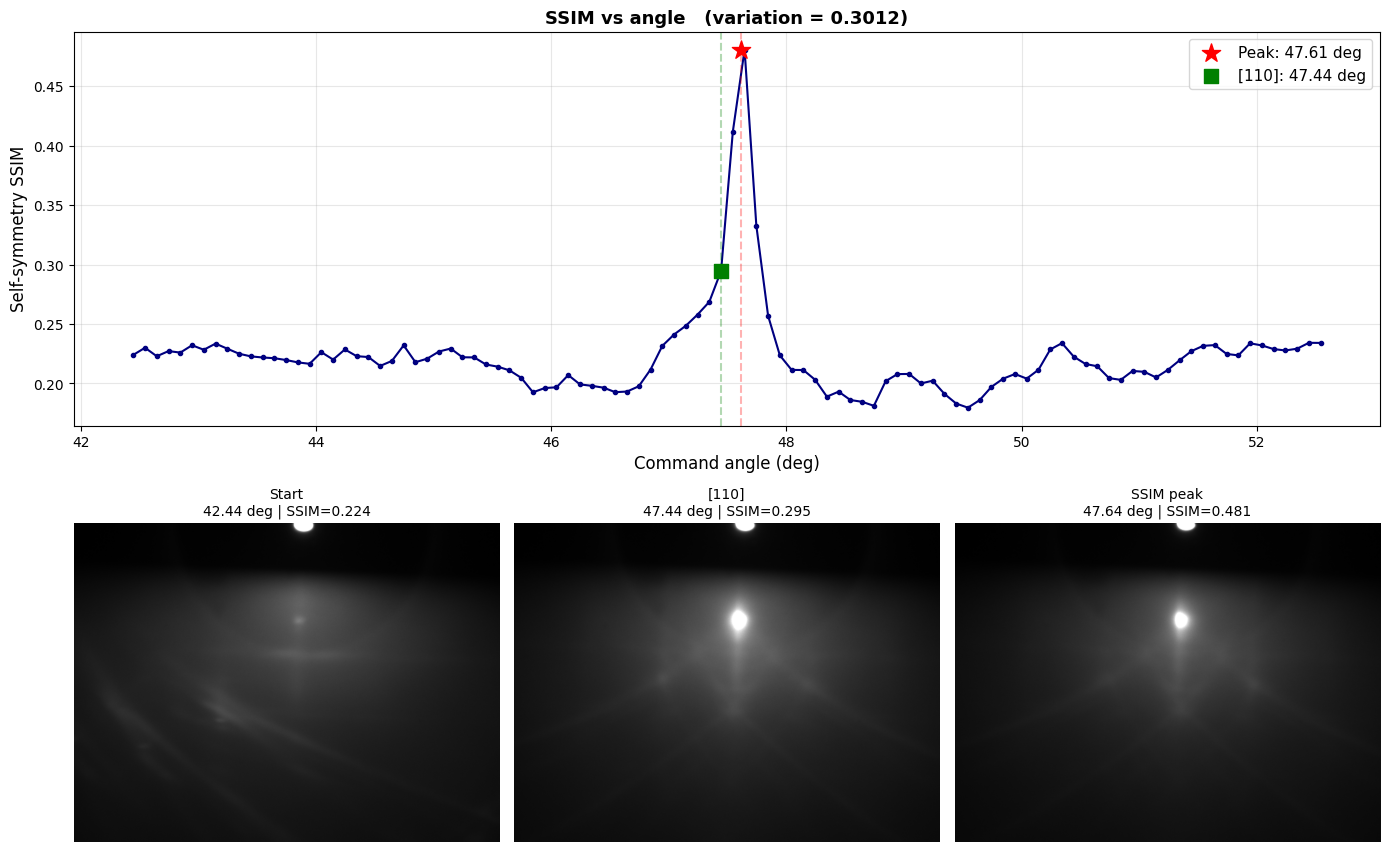

In [13]:
idx_start = 0
idx_110   = int(np.argmin(np.abs(angles - ZONE_110_USER)))
idx_peak  = int(np.argmin(np.abs(angles - peak_user)))

fig = plt.figure(figsize=(14, 9))
axc = plt.subplot(2, 3, (1, 3))
axc.plot(angles, scores, '-o', ms=3, lw=1.5, color='navy')
axc.scatter([peak_user], [scores[idx_peak]], color='red', s=190, marker='*', zorder=5,
            label=f'Peak: {peak_user:.2f} deg')
axc.scatter([ZONE_110_USER], [scores[idx_110]], color='green', s=90, marker='s', zorder=5,
            label=f'[110]: {ZONE_110_USER:.2f} deg')
axc.axvline(peak_user, color='red', ls='--', alpha=0.3)
axc.axvline(ZONE_110_USER, color='green', ls='--', alpha=0.3)
axc.set_xlabel('Command angle (deg)', fontsize=12)
axc.set_ylabel('Self-symmetry SSIM', fontsize=12)
axc.set_title(f'SSIM vs angle   (variation = {scores.max() - scores.min():.4f})',
              fontsize=13, fontweight='bold')
axc.legend(fontsize=11); axc.grid(alpha=0.3)

for sub, (ii, lab) in zip((4, 5, 6),
                          [(idx_start, 'Start'), (idx_110, '[110]'), (idx_peak, 'SSIM peak')]):
    a = plt.subplot(2, 3, sub)
    a.imshow(np.squeeze(frames[ii]), cmap='gray')
    a.set_title(f'{lab}\n{angles[ii]:.2f} deg | SSIM={scores[ii]:.3f}', fontsize=10)
    a.axis('off')

plt.tight_layout()
OUTPUT_FIG = f'{DATA_PREFIX}_ssim_paper.png'
plt.savefig(OUTPUT_FIG, dpi=200, bbox_inches='tight')
print('Saved figure:', OUTPUT_FIG)
plt.show()

## 9. What happens WITHOUT DoG (comparison)

Reruns the **same** pipeline but **skips the DoG band-pass**
(tilt-correct -> mask beam -> standardize -> SSIM). The example-frame mirror comparison and the
full SSIM-vs-angle curve are shown together, with the DoG version overlaid.

**What this dataset actually shows (note: not the textbook "variation collapses" story):**

- Without DoG the mirror halves are dominated by the **smooth, slowly-varying background**
  (top row - just soft gradients). That background is itself fairly mirror-symmetric, so the SSIM
  **baseline is high everywhere** (~0.4-0.5, vs ~0.2 with DoG).
- The peak is still near [110], but it is **broad and rounded and sits on a high pedestal**, so the
  exact angle is harder to localize. The raw max-min variation can even look slightly *larger*
  without DoG, because the broad background drifts across the scan.
- With DoG the background is removed, the baseline drops, and the diffraction features produce a
  **sharp, well-localized peak** at the alignment angle.

So in this case the benefit of DoG is **not** a bigger max-min span - it is a **sharper, lower-
pedestal, better-localized peak**, which is what lets the Gaussian peak-finder pin the angle
reliably. Run the cell and compare the two curves directly.

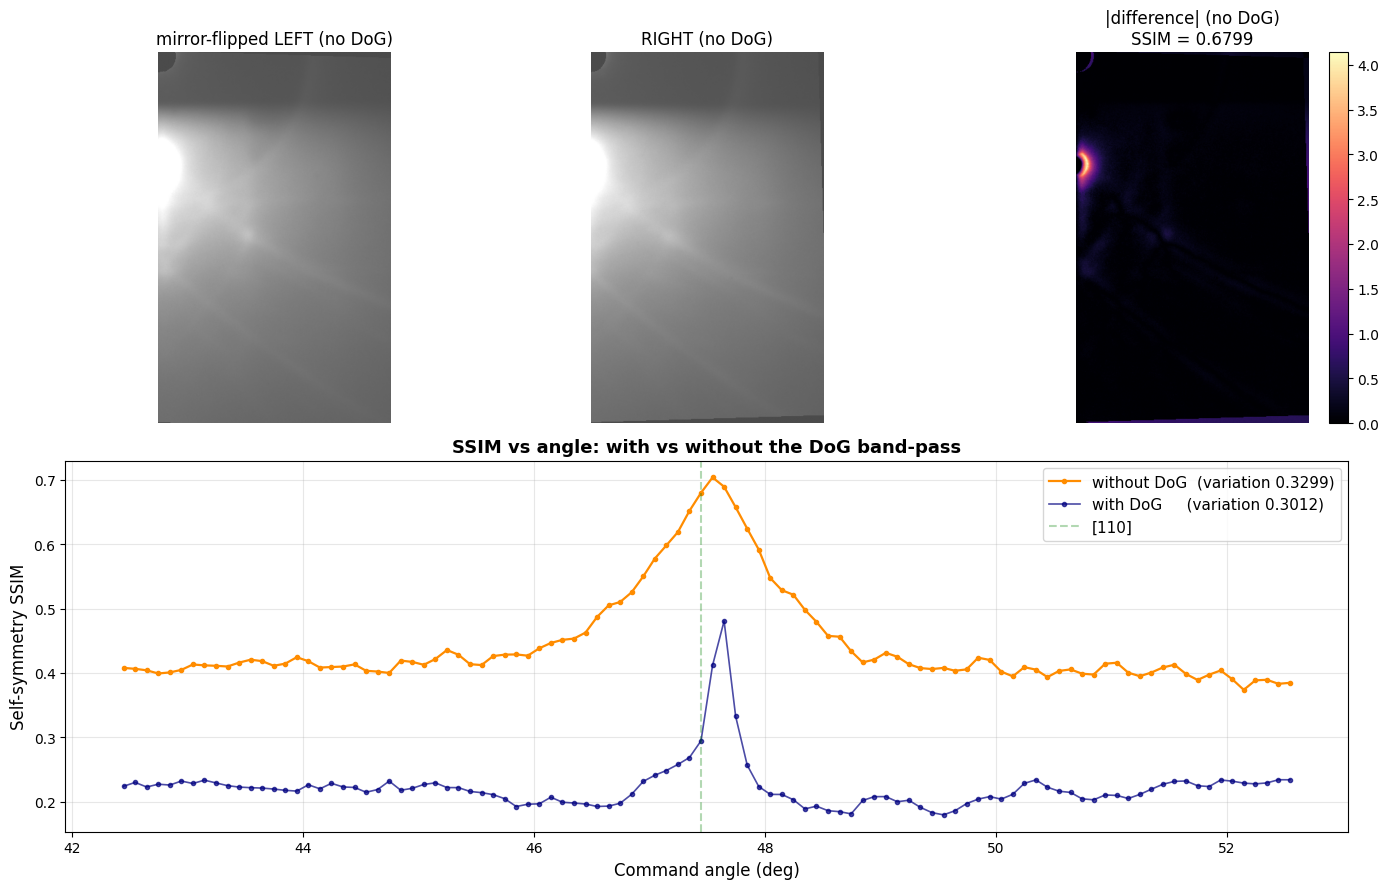

variation WITHOUT DoG : 0.32992
variation WITH    DoG : 0.30115


In [14]:
# Same pipeline but WITHOUT the DoG band-pass (the only step removed)
def process_frame_no_dog(frame):
    img = frame.astype(float).copy()
    bmask = beam_mask
    if APPLY_TILT_CORRECTION and abs(tilt_angle) > 0.1:
        img   = rotate(img, -tilt_angle, reshape=False, order=1)
        bmask = rotate(beam_mask.astype(float), -tilt_angle, reshape=False, order=0) > 0.5
    img[bmask] = 0
    s = img.std()
    if s > 0:
        img = (img - img.mean()) / s        # standardize, but NO DoG
    return img

# (a) example frame: mirror-flipped LEFT / RIGHT / difference, without DoG
proc_nd = process_frame_no_dog(frames[EXAMPLE_IDX])
m = max(10, min(W - 10, midline))
left_nd, right_nd = proc_nd[:, :m], proc_nd[:, m:]
wnd = min(left_nd.shape[1], right_nd.shape[1])
left_nd, right_nd = left_nd[:, -wnd:], right_nd[:, :wnd]
left_nd_flip = np.flip(left_nd, axis=1)
win_nd = min(SSIM_WIN, wnd // 2 * 2 + 1)
score_nd_example = ssim(left_nd_flip, right_nd, channel_axis=-1, win_size=win_nd, data_range=1.0)

# (b) SSIM vs angle for every frame, without DoG
scores_no_dog = np.array([self_symmetry_ssim(process_frame_no_dog(fr), midline) for fr in frames])

# ---- plot: top row = mirror comparison (no DoG), bottom = SSIM-vs-angle ----
fig = plt.figure(figsize=(14, 9))
v = np.percentile(np.abs(np.squeeze(proc_nd)), 99)

ax0 = plt.subplot(2, 3, 1)
ax0.imshow(np.squeeze(left_nd_flip), cmap='gray', vmin=-v, vmax=v)
ax0.set_title('mirror-flipped LEFT (no DoG)'); ax0.axis('off')

ax1 = plt.subplot(2, 3, 2)
ax1.imshow(np.squeeze(right_nd), cmap='gray', vmin=-v, vmax=v)
ax1.set_title('RIGHT (no DoG)'); ax1.axis('off')

d_nd = np.abs(np.squeeze(left_nd_flip) - np.squeeze(right_nd))
ax2 = plt.subplot(2, 3, 3)
im = ax2.imshow(d_nd, cmap='magma')
ax2.set_title(f'|difference| (no DoG)\nSSIM = {score_nd_example:.4f}'); ax2.axis('off')
fig.colorbar(im, ax=ax2, fraction=0.046)

axc = plt.subplot(2, 1, 2)
axc.plot(angles, scores_no_dog, '-o', ms=3, lw=1.6, color='darkorange',
         label=f'without DoG  (variation {scores_no_dog.max() - scores_no_dog.min():.4f})')
if 'scores' in globals():
    axc.plot(angles, scores, '-o', ms=3, lw=1.2, color='navy', alpha=0.7,
             label=f'with DoG     (variation {scores.max() - scores.min():.4f})')
axc.axvline(ZONE_110_USER, color='green', ls='--', alpha=0.3, label='[110]')
axc.set_xlabel('Command angle (deg)', fontsize=12)
axc.set_ylabel('Self-symmetry SSIM', fontsize=12)
axc.set_title('SSIM vs angle: with vs without the DoG band-pass', fontsize=13, fontweight='bold')
axc.legend(fontsize=11); axc.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'variation WITHOUT DoG : {scores_no_dog.max() - scores_no_dog.min():.5f}')
if 'scores' in globals():
    print(f'variation WITH    DoG : {scores.max() - scores.min():.5f}')

## 10. Shadow-edge detection (Sobel)

Detects the horizontal shadow edge on **frame 0** with a Sobel horizontal-edge filter (`|Sobel_h|`),
averaged across central columns into a row profile. The **strongest edge just below the direct-beam
spot** is taken as the shadow edge (beam itself skipped via `BEAM_CLEAR`). On the 10 deg set this is
row ~97; on the 5 deg set ~92. Tune `BEAM_CLEAR` / `SMOOTH_SIGMA` if needed.

beam (y,x)=(7,387) r=19 | shadow edge row = 92


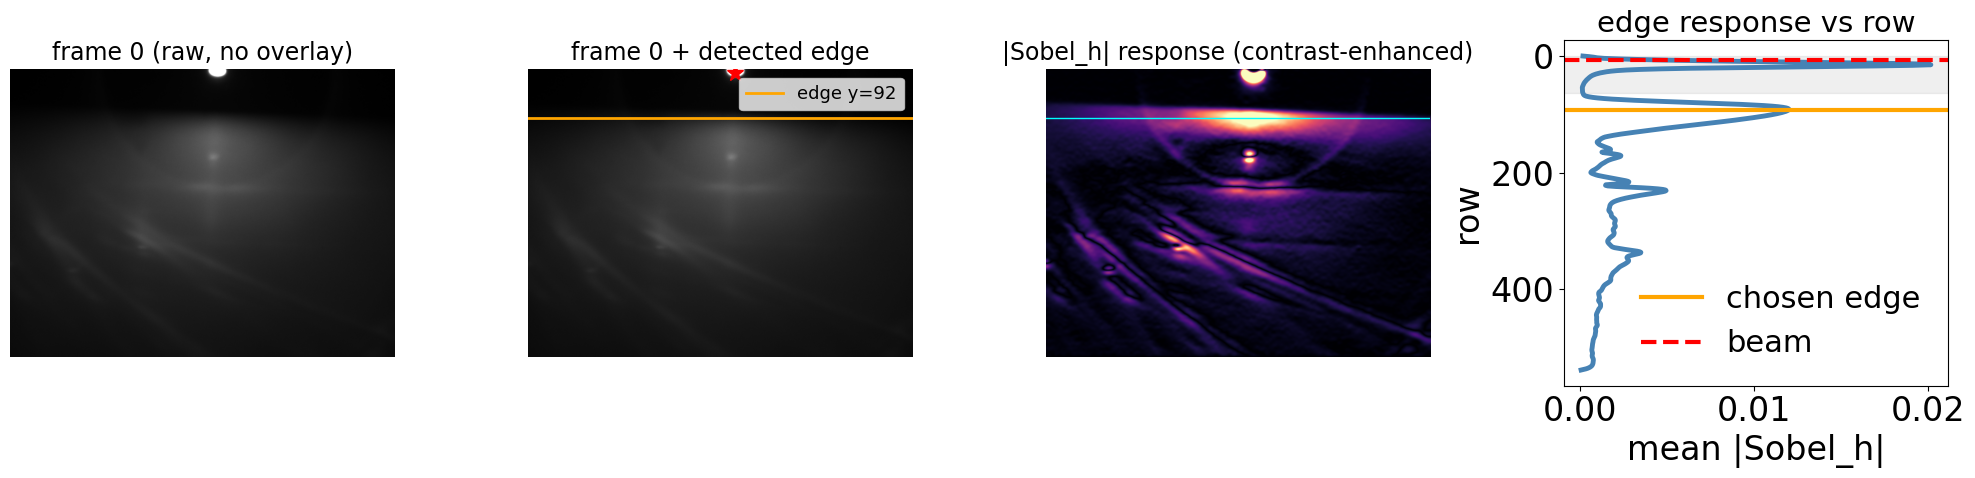

In [15]:
# === Detect the horizontal shadow edge below the direct beam (Sobel) - frame 0 ===
from scipy.ndimage import label, gaussian_filter
from skimage.filters import sobel_h

# --- knobs ---
SMOOTH_SIGMA = 3      # pre-smoothing before the Sobel filter
BEAM_CLEAR   = 3      # start the edge search this many beam-radii below the beam spot
COL_HALF     = 150    # central column half-width used for the row profile

g0 = np.squeeze(frames[0]).astype(float)
H, W = g0.shape
g0n = (g0 - g0.min()) / (g0.max() - g0.min() + 1e-9)

# direct beam (brightest blob in the top half)
top = np.zeros((H, W), bool); top[:H // 2, :] = True
ss = g0.copy(); ss[~top] = 0
lab, nlab = label(ss > np.percentile(g0, 99.5))
bi = max(range(1, nlab + 1), key=lambda i: g0[lab == i].mean())
ys, xs = np.where(lab == bi)
b_y, b_x = ys.mean(), xs.mean()
b_r = np.sqrt((ys - b_y) ** 2 + (xs - b_x) ** 2).max()
b_y, b_x = int(b_y), int(b_x)

# horizontal-edge (Sobel) response -> 1-D row profile over central columns
resp = np.abs(sobel_h(gaussian_filter(g0n, sigma=SMOOTH_SIGMA)))
band = slice(max(0, b_x - COL_HALF), min(W, b_x + COL_HALF))
prof = resp[:, band].mean(axis=1)

# strongest horizontal edge just below the direct-beam spot
lo = int(b_y + BEAM_CLEAR * b_r)
edge_y = lo + int(np.argmax(prof[lo:H - 5]))
print(f'beam (y,x)=({b_y},{b_x}) r={b_r:.0f} | shadow edge row = {edge_y}')

# --- visualize ---
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14,
                     'legend.fontsize': 13, 'lines.linewidth': 2.5, 'lines.markersize': 6})
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# (0) RAW frame, no overlay - see the shadow edge naturally
ax[0].imshow(g0, cmap='gray')
ax[0].set_title('frame 0 (raw, no overlay)'); ax[0].axis('off')

# (1) raw frame with the detected edge marked
ax[1].imshow(g0, cmap='gray')
ax[1].axhline(edge_y, color='orange', lw=2, label=f'edge y={edge_y}')
ax[1].plot(b_x, b_y, 'r*', ms=12)
ax[1].set_title('frame 0 + detected edge'); ax[1].axis('off'); ax[1].legend(fontsize=13)

# (2) Sobel horizontal-edge response
# scale the colormap to the response BELOW the beam, so the beam saturates and the
# much weaker shadow edge / streak features become visible (otherwise the bright
# beam sets vmax and crushes everything else to black)
v_resp = np.percentile(resp[lo:H - 5], 99.5)
ax[2].imshow(resp, cmap='magma', vmin=0, vmax=v_resp)
ax[2].axhline(edge_y, color='cyan', lw=1)
ax[2].set_title('|Sobel_h| response (contrast-enhanced)'); ax[2].axis('off')

# (3) row profile
ax[3].plot(prof, np.arange(H), color='steelblue', lw=3.5)
ax[3].axhline(edge_y, color='orange', lw=3, label='chosen edge')
ax[3].axhline(b_y, color='red', ls='--', lw=3, label='beam')
ax[3].axhspan(0, lo, color='gray', alpha=0.12)
ax[3].invert_yaxis()
ax[3].set_xlabel('mean |Sobel_h|', fontsize=24); ax[3].set_ylabel('row', fontsize=24)
ax[3].tick_params(labelsize=24)
ax[3].locator_params(axis='x', nbins=4)   # fewer x ticks (declutter)
ax[3].set_title('edge response vs row', fontsize=21); ax[3].legend(fontsize=22, frameon=False)

plt.tight_layout()
os.makedirs('figure for paper', exist_ok=True)
plt.savefig(f'figure for paper/{DATA_PREFIX}_fig_sobel_edge.png', dpi=600, transparent=True, bbox_inches='tight')
def _save_panel(fig, axes_all, a, path, pad=0.02):
    others = [x for x in axes_all if x is not a]
    for x in others: x.set_visible(False)          # hide neighbours so they don't bleed in
    fig.canvas.draw(); r = fig.canvas.get_renderer()
    bb = a.get_tightbbox(r).transformed(fig.dpi_scale_trans.inverted()).expanded(1 + pad, 1 + pad)
    fig.savefig(path, bbox_inches=bb, dpi=600, transparent=True)
    for x in others: x.set_visible(True)
_axes = list(np.ravel(ax))
for _a, _nm in zip(_axes, ['raw', 'detected_edge', 'sobel_response', 'edge_profile']):
    _save_panel(fig, _axes, _a, f'figure for paper/{DATA_PREFIX}_panel_{_nm}.png')
plt.show()

## 11. Tilt-corrected alignment using the Sobel shadow edge

Puts it together into a robust, automatic method:

1. **Fit the (sloped) shadow edge** on frame 0 with the Sobel filter (Section 10) - the **slope is
   the detector tilt**.
2. **De-rotate every frame about the direct beam** so the edge becomes horizontal and the mirror
   axis is vertical through the beam.
3. **Apply the self-symmetry SSIM** (Steps 1-4 + scoring) on the region **below the edge**.

No specular detection, no manual input. Tilt comes from frame 0 only (fast). Validated: recovers
injected tilts of -10 deg ... +10 deg with the correct peak.

beam x=387 | edge slope=+0.0324 -> tilt=+1.9 deg | edge row at beam=91
peak = 47.554 deg   variation = 0.4815


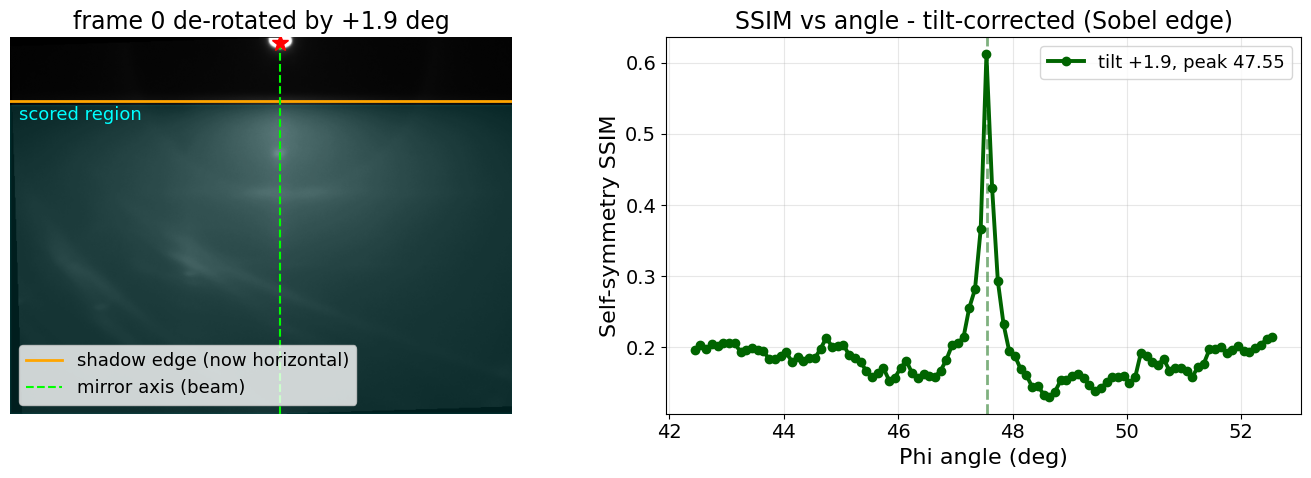

In [16]:
from scipy.ndimage import label, gaussian_filter, affine_transform
from skimage.filters import sobel_h

# --- parameters ---
EDGE_SMOOTH = 3     # Sobel pre-smoothing
BEAM_CLEAR  = 3     # skip this many beam-radii below the beam when finding the edge
EDGE_WIN    = 40    # +/- rows around the global edge used for the per-column line fit
REGION_PAD  = 5     # start the SSIM region this many rows below the edge

Fg = np.squeeze(frames).astype(float)
Nn, Hh, Ww = Fg.shape

def _beam(img):
    half = np.zeros((Hh, Ww), bool); half[:Hh // 2, :] = True
    s = img.copy(); s[~half] = 0
    lab, nl = label(s > np.percentile(img, BEAM_DETECTION_THRESHOLD))
    bi = max(range(1, nl + 1), key=lambda i: img[lab == i].mean())
    ys, xs = np.where(lab == bi); cy, cx = ys.mean(), xs.mean()
    return float(cy), float(cx), float(np.sqrt((ys - cy) ** 2 + (xs - cx) ** 2).max())

def _derotate(img, cy, cx, theta):
    th = np.deg2rad(-theta); c, s = np.cos(th), np.sin(th)
    R = np.array([[c, -s], [s, c]]); off = np.array([cy, cx]) - R @ np.array([cy, cx])
    return affine_transform(img, R, offset=off, order=1, mode='constant', cval=0.0)

def _edge_fit(img, cy, cx, br):
    g = (img - img.min()) / (img.max() - img.min() + 1e-9)
    resp = np.abs(sobel_h(gaussian_filter(g, sigma=EDGE_SMOOTH)))
    lo = int(cy + BEAM_CLEAR * br)
    bnd = slice(max(0, int(cx) - 150), int(cx) + 150)
    e0 = lo + int(np.argmax(resp[lo:Hh - 5, bnd].mean(1)))
    cols = np.arange(max(0, int(cx) - 250), min(Ww, int(cx) + 250))
    sub = resp[e0 - EDGE_WIN:e0 + EDGE_WIN, cols]
    ey = e0 - EDGE_WIN + np.argmax(sub, axis=0); pv = sub.max(axis=0)
    keep = pv > np.percentile(pv, 50)
    m, c = np.polyfit(cols[keep], ey[keep], 1)
    return float(m), float(c), e0

# 1) detect beam + fit the sloped shadow edge -> tilt
cy, cx, br = _beam(Fg[0])
m, c, e0 = _edge_fit(Fg[0], cy, cx, br)
tilt_mag = np.degrees(np.arctan(m))
def _resid(t):
    mm, _, _ = _edge_fit(_derotate(Fg[0], cy, cx, t), cy, cx, br); return abs(mm)
tilt = min((+tilt_mag, -tilt_mag), key=_resid)          # sign that flattens the edge
edge_row = int(m * cx + c)
region_top = edge_row + REGION_PAD
print(f'beam x={cx:.0f} | edge slope={m:+.4f} -> tilt={tilt:+.1f} deg | edge row at beam={edge_row}')

# 2) + 3) de-rotate each frame about the beam, then self-symmetry SSIM below the edge
Y, X = np.ogrid[:Hh, :Ww]
beam_mask = (Y - cy) ** 2 + (X - cx) ** 2 <= (br + BEAM_MASK_EXPANSION) ** 2
mid = int(max(10, min(Ww - 10, cx)))

def _score(fr):
    g = _derotate(fr, cy, cx, tilt); g[beam_mask] = 0
    f = difference_of_gaussians(g, DOG_LOW_SIGMA, DOG_HIGH_SIGMA); sd = f.std()
    if sd > 0: f = (f - f.mean()) / sd
    p = f[region_top:Hh - 2]
    Lh, Rh = p[:, :mid], p[:, mid:]; w = min(Lh.shape[1], Rh.shape[1])
    if w < 10: return 0.0
    Lh, Rh = Lh[:, -w:], Rh[:, :w]; win = min(SSIM_WIN, w // 2 * 2 + 1)
    return ssim(np.flip(Lh, 1), Rh, win_size=win, data_range=1.0) if win >= 3 else 0.0

scores_edge = np.array([_score(fr) for fr in Fg])
peak_edge, _, _ = find_peak(angles, scores_edge)
print(f'peak = {peak_edge:.3f} deg   variation = {scores_edge.max() - scores_edge.min():.4f}')

# 4) figure
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14,
                     'legend.fontsize': 13, 'lines.linewidth': 2.5, 'lines.markersize': 6})
fig = plt.figure(figsize=(14, 5))
axd = plt.subplot(1, 2, 1)
axd.imshow(_derotate(Fg[0], cy, cx, tilt), cmap='gray')
axd.axhline(edge_row, color='orange', lw=2, label='shadow edge (now horizontal)')
axd.axvline(cx, color='lime', ls='--', lw=1.5, label='mirror axis (beam)')
axd.axhspan(region_top, Hh - 2, color='cyan', alpha=0.12)
axd.text(12, region_top + 22, 'scored region', color='cyan', fontsize=13)
axd.plot(cx, cy, 'r*', ms=12)
axd.set_title(f'frame 0 de-rotated by {tilt:+.1f} deg'); axd.axis('off'); axd.legend(fontsize=13)

axc = plt.subplot(1, 2, 2)
axc.plot(angles, scores_edge, '-o', ms=6, lw=2.8, color='darkgreen',
         label=f'tilt {tilt:+.1f}, peak {peak_edge:.2f}')
axc.axvline(peak_edge, color='darkgreen', ls='--', alpha=0.5, lw=2)
axc.set_xlabel('Phi angle (deg)'); axc.set_ylabel('Self-symmetry SSIM')
axc.set_title('SSIM vs angle - tilt-corrected (Sobel edge)'); axc.legend(fontsize=13); axc.grid(alpha=0.3)
plt.tight_layout()
os.makedirs('figure for paper', exist_ok=True)
plt.savefig(f'figure for paper/{DATA_PREFIX}_fig_ssim_curve.png', dpi=600, transparent=True, bbox_inches='tight')
def _save_panel(fig, axes_all, a, path, pad=0.02):
    others = [x for x in axes_all if x is not a]
    for x in others: x.set_visible(False)          # hide neighbours so they don't bleed in
    fig.canvas.draw(); r = fig.canvas.get_renderer()
    bb = a.get_tightbbox(r).transformed(fig.dpi_scale_trans.inverted()).expanded(1 + pad, 1 + pad)
    fig.savefig(path, bbox_inches=bb, dpi=600, transparent=True)
    for x in others: x.set_visible(True)
_axes = [axd, axc]
_save_panel(fig, _axes, axd, f'figure for paper/{DATA_PREFIX}_panel_derotated_frame.png')
_save_panel(fig, _axes, axc, f'figure for paper/{DATA_PREFIX}_panel_ssim_curve.png')
plt.show()

## 11b. SSIM at diiferent locations (~37.5 and ~57.5 deg)

The end frames also score high - but for a different reason than the [110] peak. At the scan ends the
diffraction pattern is **faint and diffuse** (a smooth glow with few sharp features). A smooth,
feature-poor image is **trivially near mirror-symmetric** - the `|flip(left) - right|` map is almost
dark - so SSIM is high simply because there is little structure to break the symmetry. 




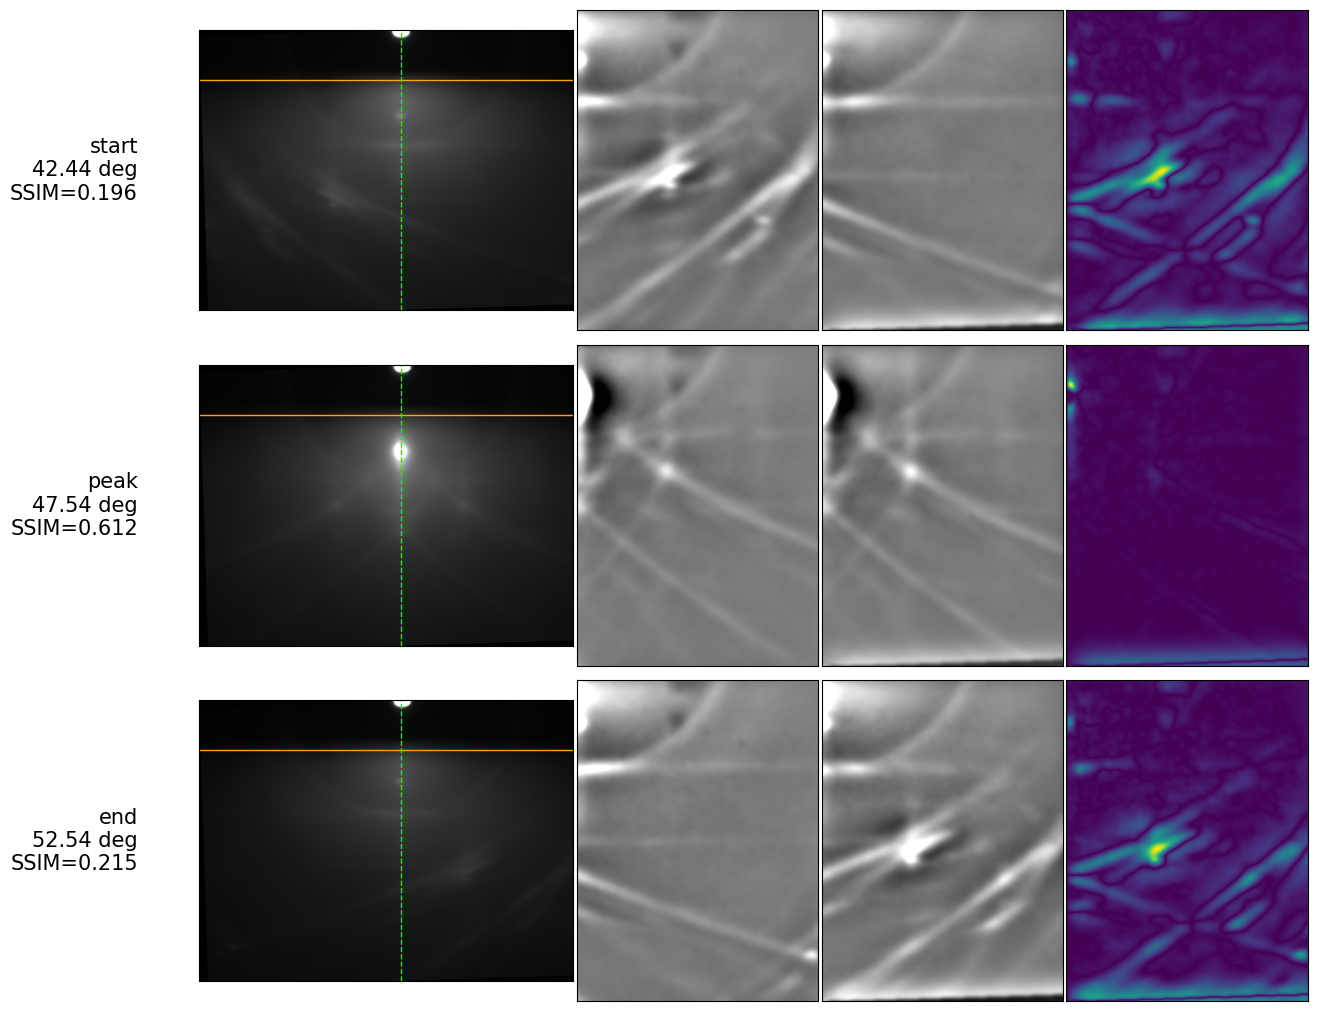

In [17]:
# RHEED frames at the scan extremes vs the peak, with the mirror halves SSIM compares.
# Columns: de-rotated RHEED frame | mirror-flipped LEFT | RIGHT | |difference|  (cf. Section 5)
# Extremes are taken from the actual scan range, so it adapts to any dataset.
picks = [('start', float(angles.min())),
         ('peak',  float(peak_edge)),
         ('end',   float(angles.max()))]

plt.rcParams.update({'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14,
                     'legend.fontsize': 13, 'lines.linewidth': 2.5, 'lines.markersize': 6})
fig, ax = plt.subplots(3, 4, figsize=(13, 10), constrained_layout=True,
                       gridspec_kw={'width_ratios': [1.55, 1, 1, 1]})
fig.set_constrained_layout_pads(w_pad=0.01, h_pad=0.02, wspace=0.01, hspace=0.03)
headers = ['de-rotated RHEED frame', 'mirror-flipped LEFT', 'RIGHT', '|difference|']

for r, (name, a) in enumerate(picks):
    i = int(np.argmin(np.abs(angles - a)))
    g = _derotate(Fg[i], cy, cx, tilt)
    gm = g.copy(); gm[beam_mask] = 0
    f = difference_of_gaussians(gm, DOG_LOW_SIGMA, DOG_HIGH_SIGMA)
    sd = f.std()
    if sd > 0: f = (f - f.mean()) / sd
    p = f[region_top:Hh - 2]
    Lh, Rh = p[:, :mid], p[:, mid:]; w = min(Lh.shape[1], Rh.shape[1])
    Lf, Rr = np.flip(Lh[:, -w:], 1), Rh[:, :w]
    v = np.percentile(np.abs(p), 99)

    ax[r, 0].imshow(g, cmap='gray')
    ax[r, 0].axhline(region_top, color='orange', lw=1)
    ax[r, 0].axvline(cx, color='lime', ls='--', lw=1)
    ax[r, 1].imshow(Lf, cmap='gray', vmin=-v, vmax=v)
    ax[r, 2].imshow(Rr, cmap='gray', vmin=-v, vmax=v)
    ax[r, 3].imshow(np.abs(Lf - Rr), cmap='viridis')
    for cc in range(4):
        ax[r, cc].set_xticks([]); ax[r, cc].set_yticks([])
    # row label on the left (does not overlap the panels)
    ax[r, 0].set_ylabel(f'{name}\n{angles[i]:.2f} deg\nSSIM={scores_edge[i]:.3f}',
                        rotation=0, ha='right', va='center', fontsize=15, labelpad=44)


# column headers on the top row only (commented out)
# for cc, h in enumerate(headers):
#     ax[0, cc].set_title(h, fontsize=16)

os.makedirs('figure for paper', exist_ok=True)
plt.savefig(f'figure for paper/{DATA_PREFIX}_fig_halves_grid.png', dpi=600, transparent=True, bbox_inches='tight')
plt.show()